# EP2  Machine Learning: Spotify Tracks

## 1. EDA y preparacion de datos

Este notebook contiene la exploracion inicial y prepara los conjuntos Train/Test para el modelamiento.

**Dataset esperado:** `Data/Raw/Spotify_Tracks_Dataset.csv`

In [12]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT / "Data").exists():
    ROOT = ROOT.parent.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from preprocess import clean_dataset, split_and_save_data
from grafico import save_histogram, save_barh

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
print("Ruta del proyecto:", ROOT)

Ruta del proyecto: C:\Users\Roma\Documents\proyectos dudoc\Spotify_ML_GitHub


## 2. Carga del dataset

In [13]:
DATA_PATH = ROOT / "Data" / "Raw" / "Spotify_Tracks_Dataset.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontro {DATA_PATH}. Copia el CSV original en Data/Raw/")

df = pd.read_csv(DATA_PATH)
print("Dataset cargado:", df.shape)
display(df.head())

Dataset cargado: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 3. Comprension y calidad de los datos

In [14]:
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
display(df.dtypes.to_frame("tipo"))
print("\nInformacion general:")
df.info()
print("\nEstadisticas descriptivas:")
display(df.describe(include="all").T)

Dimensiones: (114000, 21)

Tipos de datos:


,tipo
Unnamed: 0,int64
track_id,str
artists,str
album_name,str
track_name,str
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64



Informacion general:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,NaN,NaN,NaN,56999.5,32909.109681,0.0,28499.75,56999.5,85499.25,113999.0
track_id,114000,89741,6S3JlDAGk3uu3NtZbPnuhS,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artists,113999,31437,The Beatles,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_name,113999,46589,Alternative Christmas 2022,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,113999,73608,Run Rudolph Run,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,114000.0,NaN,NaN,NaN,33.238535,22.305078,0.0,17.0,35.0,50.0,100.0
duration_ms,114000.0,NaN,NaN,NaN,228029.153114,107297.712645,0.0,174066.0,212906.0,261506.0,5237295.0
explicit,114000,2,False,104253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,114000.0,NaN,NaN,NaN,0.5668,0.173542,0.0,0.456,0.58,0.695,0.985
energy,114000.0,NaN,NaN,NaN,0.641383,0.251529,0.0,0.472,0.685,0.854,1.0


### 3.1 Valores faltantes

In [15]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(3)
missing_table = pd.DataFrame({"valores_faltantes": missing, "porcentaje": missing_pct})
display(missing_table[missing_table["valores_faltantes"] > 0])

,valores_faltantes,porcentaje
artists,1,0.001
track_name,1,0.001
album_name,1,0.001


### 3.2 Duplicados

In [16]:
print("Filas duplicadas completas:", df.duplicated().sum())
print("IDs de track repetidos:", df["track_id"].duplicated().sum())
print("IDs unicos:", df["track_id"].nunique())

Filas duplicadas completas: 0
IDs de track repetidos: 24259
IDs unicos: 89741


## 4. Distribucion de la popularidad

In [17]:
print(df["popularity"].describe())
path = save_histogram(df["popularity"], "Distribucion de la popularidad de las canciones", "Popularidad", "Cantidad", ROOT / "output/Graficos/distribucion_popularidad.png", bins=20)
print("Grafico guardado en:", path)

count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64
Grafico guardado en: C:\Users\Roma\Documents\proyectos dudoc\Spotify_ML_GitHub\output\Graficos\distribucion_popularidad.png


## 5. Distribucion de variables musicales

In [18]:
audio_features = ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo", "duration_ms"]
display(df[audio_features].describe().T)
for col in ["danceability", "energy", "acousticness", "valence"]:
    path = save_histogram(df[col], f"Distribucion de {col}", col, "Cantidad", ROOT / f"output/Graficos/distribucion_{col}.png", bins=20)
    print(path)

,count,mean,std,min,25%,50%,75%,max
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996
instrumentalness,114000.0,0.156050,0.309555,0.000,0.00000,0.000042,0.0490,1.000
liveness,114000.0,0.213553,0.190378,0.000,0.09800,0.132000,0.2730,1.000
valence,114000.0,0.474068,0.259261,0.000,0.26000,0.464000,0.6830,0.995
tempo,114000.0,122.147837,29.978197,0.000,99.21875,122.017000,140.0710,243.372
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000


C:\Users\Roma\Documents\proyectos dudoc\Spotify_ML_GitHub\output\Graficos\distribucion_danceability.png
C:\Users\Roma\Documents\proyectos dudoc\Spotify_ML_GitHub\output\Graficos\distribucion_energy.png
C:\Users\Roma\Documents\proyectos dudoc\Spotify_ML_GitHub\output\Graficos\distribucion_acousticness.png
C:\Users\Roma\Documents\proyectos dudoc\Spotify_ML_GitHub\output\Graficos\distribucion_valence.png


## 6. Popularidad promedio por genero

In [19]:
genre_popularity = (df.groupby("track_genre")["popularity"].agg(["count","mean","median"]).sort_values("mean", ascending=False))
display(genre_popularity.head(15))
top_genres = genre_popularity.head(15).sort_values("mean")
path = save_barh(top_genres.index, top_genres["mean"], "15 generos con mayor popularidad promedio", "Popularidad", ROOT / "output/Graficos/popularidad_por_genero.png")
print(path)

,count,mean,median
track_genre,,,
pop-film,1000,59.283,60.0
k-pop,1000,56.896,60.0
chill,1000,53.651,57.0
sad,1000,52.379,54.0
grunge,1000,49.594,55.0
indian,1000,49.539,49.0
anime,1000,48.772,50.0
emo,1000,48.128,51.0
sertanejo,1000,47.866,47.0


C:\Users\Roma\Documents\proyectos dudoc\Spotify_ML_GitHub\output\Graficos\popularidad_por_genero.png


## 7. Relaciones entre variables

popularity          1.000000
loudness            0.050423
danceability        0.035448
Unnamed: 0          0.032142
time_signature      0.031073
tempo               0.013205
energy              0.001056
key                -0.003853
liveness           -0.005387
duration_ms        -0.007101
mode               -0.013931
acousticness       -0.025472
valence            -0.040534
speechiness        -0.044927
instrumentalness   -0.095139
Name: popularity, dtype: float64

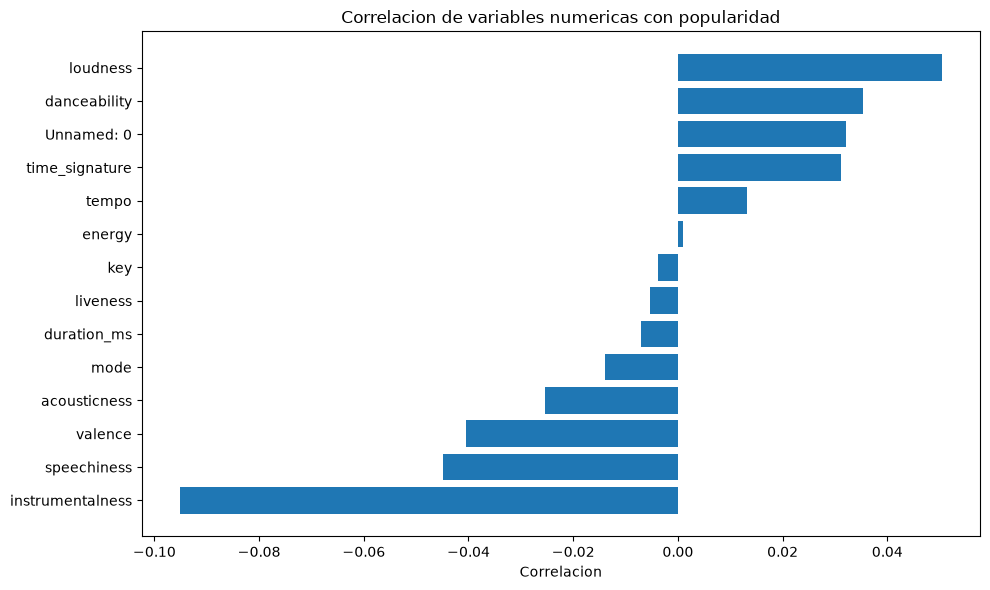

C:\Users\Roma\Documents\proyectos dudoc\Spotify_ML_GitHub\output\Graficos\correlacion_popularidad.png


In [20]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr_with_popularity = df[numeric_cols].corr(numeric_only=True)["popularity"].sort_values(ascending=False)
display(corr_with_popularity)
fig, ax = plt.subplots(figsize=(10,6))
s = corr_with_popularity.drop("popularity").sort_values()
ax.barh(s.index, s.values)
ax.set_title("Correlacion de variables numericas con popularidad")
ax.set_xlabel("Correlacion")
fig.tight_layout()
path = ROOT / "output/Graficos/correlacion_popularidad.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(path)

## 8. Preparacion de datos

In [21]:
df_model = clean_dataset(df)
print("Filas originales:", len(df))
print("Filas despues de eliminar track_id repetidos:", len(df_model))
print("Columnas utilizadas:")
print(df_model.columns.tolist())

X = df_model.drop(columns=["popularity"])
y = df_model["popularity"]
categorical_features = ["track_genre"]
numeric_features = [c for c in X.columns if c not in categorical_features]
print("Variables numericas:", numeric_features)
print("Variables categoricas:", categorical_features)

Filas originales: 114000
Filas despues de eliminar track_id repetidos: 89741
Columnas utilizadas:
['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']
Variables numericas: ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Variables categoricas: ['track_genre']


## 9. Division Train/Test y guardado

In [22]:
paths = split_and_save_data(df_model, ROOT / "Data/Processed", test_size=0.20, random_state=RANDOM_STATE)
print("Archivos procesados creados:")
for k,v in paths.items(): print(k, "->", v)

Archivos procesados creados:
train -> C:\Users\Roma\Documents\proyectos dudoc\Spotify_ML_GitHub\Data\Processed\Train\train.csv
test -> C:\Users\Roma\Documents\proyectos dudoc\Spotify_ML_GitHub\Data\Processed\Test\test.csv


## 10. Cierre

Los datos quedan separados en `Data/Processed/Train` y `Data/Processed/Test`. El modelamiento se realiza en `2_Modelizacion.ipynb`.